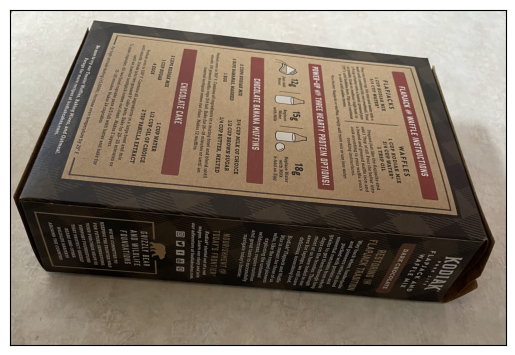

In [2]:
'''
In this question you will attempt to build a ”camscanner” equivalent code that identifies the edges of a piece
of paper, identifies the perspective transformation, and applies adaptive thresholding. You may assume that
the original paper has only 4 sides and is of rectangular shape. Your tasks are as follows;
a) Load in the image:
'''

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load in the image
img = cv2.imread('Im8.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.xticks([]), plt.yticks([])
plt.imshow(img)

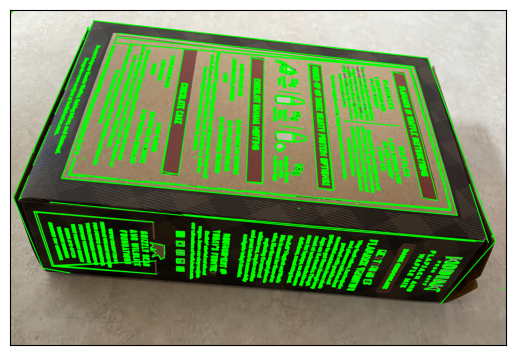

In [4]:
'''
Extract the edges. Use the command
h = drawpolygon(’FaceAlpha’,0);
to extract the corners of your ”page”. You will notice that there are two ”pages” in the image with text.
Refer the image below to see what they are. You will be performing the perspective transformation on
each of the two pages.
'''

# Draw polygon
def drawpolygon(FaceAlpha):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Apply GaussianBlur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Apply Canny
    edges = cv2.Canny(blurred, 75, 200)
    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Draw contours
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        cv2.drawContours(img, [approx], 0, (0, 255, 0), 5)
    plt.xticks([]), plt.yticks([])
    plt.imshow(img)
    
drawpolygon(0)

In [1]:
# import required libraries
import cv2
import numpy as np
drawing = False
ix,iy = -1,-1

# define mouse callback function to draw circle
def draw_rectangle(event, x, y, flags, param):
   global ix, iy, drawing, img
   if event == cv2.EVENT_LBUTTONDOWN:
      drawing = True
      ix = x
      iy = y
   elif event == cv2.EVENT_LBUTTONUP:
      drawing = False
      cv2.rectangle(img, (ix, iy),(x, y),(0, 255, 255),-1)

# Create a black image
img = cv2.imread('Im8.png')

# Create a window and bind the function to window
cv2.namedWindow("Rectangle Window")

# Connect the mouse button to our callback function
cv2.setMouseCallback("Rectangle Window", draw_rectangle)

# display the window
while True:
   cv2.imshow("Rectangle Window", img)
   if cv2.waitKey(10) == 27:
       break
cv2.destroyAllWindows()